# CIS 412 Project 1: Airline Passenger Satisfaction Analysis




This dataset contains an airline passenger satisfaction survey.
It includes 25 colums and 25976 rows, each representing an individual passenger’s travel experience, along with a mix of numerical and categorical features that describe passenger demographics, flight details, and satisfaction levels with various services offered during their journey.

The target variable indicates the passenger’s overall satisfaction level (Satisfied, Neutral, or Dissatisfied).
What factors are highly correlated to a satisfied (or dissatisfied) passenger?
Gender: Gender of the passengers (Female, Male)

Customer Type: The customer type (Loyal customer, disloyal customer)

Age: The actual age of the passengers

Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)

Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)

Flight distance: The flight distance of this journey

Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)

Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient

Ease of Online booking: Satisfaction level of online booking

Gate location: Satisfaction level of Gate location

Food and drink: Satisfaction level of Food and drink

Online boarding: Satisfaction level of online boarding

Seat comfort: Satisfaction level of Seat comfort

Inflight entertainment: Satisfaction level of inflight entertainment

On-board service: Satisfaction level of On-board service

Leg room service: Satisfaction level of Leg room service

Baggage handling: Satisfaction level of baggage handling

Check-in service: Satisfaction level of Check-in service

Inflight service: Satisfaction level of inflight service

Cleanliness: Satisfaction level of Cleanliness

Departure Delay in Minutes: Minutes delayed when departure

Arrival Delay in Minutes: Minutes delayed when Arrival

Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

train_df  = pd.read_csv("/content/train.csv.zip")
test_df = pd.read_csv("/content/test.csv.zip")

eda_df = pd.concat([train_df, test_df], ignore_index=True)
eda_df.head()


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [268]:
eda_df.shape[0]


129880

In [255]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 11  Gate location                      1298

In [256]:
eda_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,129880.0,44158.700000,31207.377062,0.0,16234.75,38963.5,71433.25,103903.0
id,129880.0,64940.500000,37493.270818,1.0,32470.75,64940.5,97410.25,129880.0
Age,129880.0,39.427957,15.119360,7.0,27.00,40.0,51.00,85.0
Flight Distance,129880.0,1190.316392,997.452477,31.0,414.00,844.0,1744.00,4983.0
Inflight wifi service,129880.0,2.728696,1.329340,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,129880.0,3.057599,1.526741,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,129880.0,2.756876,1.401740,0.0,2.00,3.0,4.00,5.0
Gate location,129880.0,2.976925,1.278520,0.0,2.00,3.0,4.00,5.0
Food and drink,129880.0,3.204774,1.329933,0.0,2.00,3.0,4.00,5.0
Online boarding,129880.0,3.252633,1.350719,0.0,2.00,3.0,4.00,5.0


In [257]:
categorical_cols = eda_df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    eda_df[col] = le.fit_transform(eda_df[col])

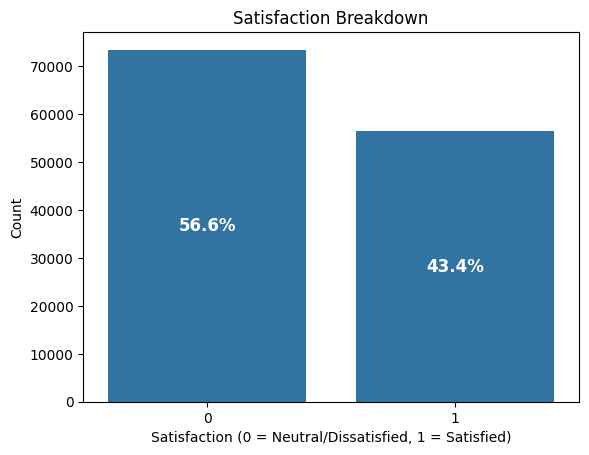

In [273]:
import matplotlib.pyplot as plt
import seaborn as sns

# Countplot
ax = sns.countplot(x='satisfaction', data=eda_df)
plt.title("Satisfaction Breakdown")
plt.xlabel("Satisfaction (0 = Neutral/Dissatisfied, 1 = Satisfied)")
plt.ylabel("Count")

# Add percentages inside the bars
total = len(eda_df)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() * 0.5
    ax.annotate(percentage, (x, y), ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.show()


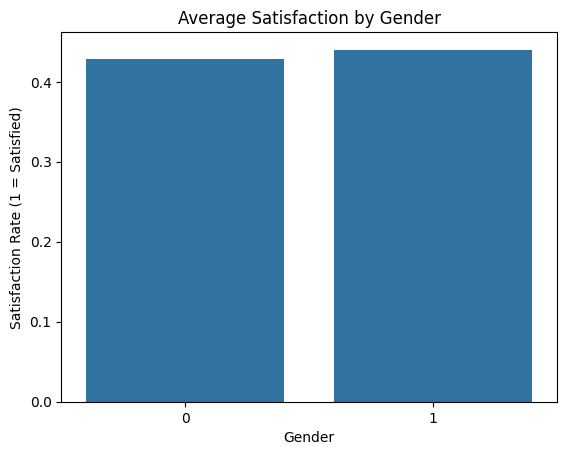

In [270]:
# Get average satisfaction by gender
avg_satisfaction = eda_df.groupby('Gender')['satisfaction'].mean().reset_index()

sns.barplot(x='Gender', y='satisfaction', data=avg_satisfaction)
plt.title("Average Satisfaction by Gender")
plt.ylabel("Satisfaction Rate (1 = Satisfied)")
plt.show()


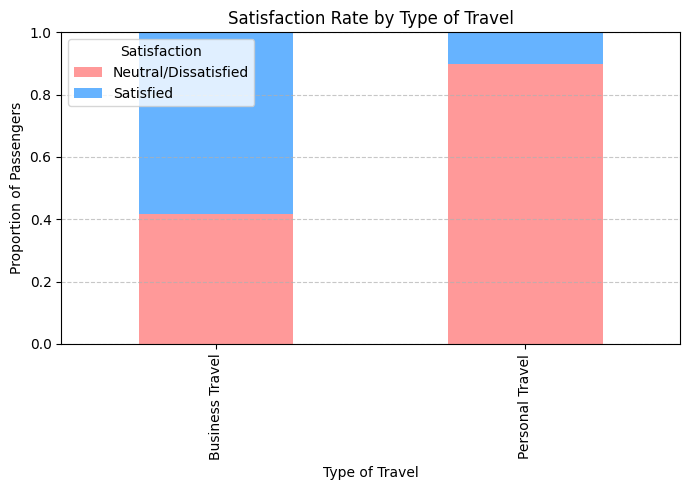

In [282]:
# Step 1: Calculate satisfaction rate per travel type
grouped = eda_df.groupby('Travel_Label')['satisfaction'].value_counts(normalize=True).unstack().reset_index()

# Step 2: Plot
grouped.plot(
    x='Travel_Label',
    kind='bar',
    stacked=True,
    color=['#ff9999','#66b3ff'],
    figsize=(7,5)
)
plt.title("Satisfaction Rate by Type of Travel")
plt.ylabel("Proportion of Passengers")
plt.xlabel("Type of Travel")
plt.legend(title='Satisfaction', labels=['Neutral/Dissatisfied', 'Satisfied'])
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




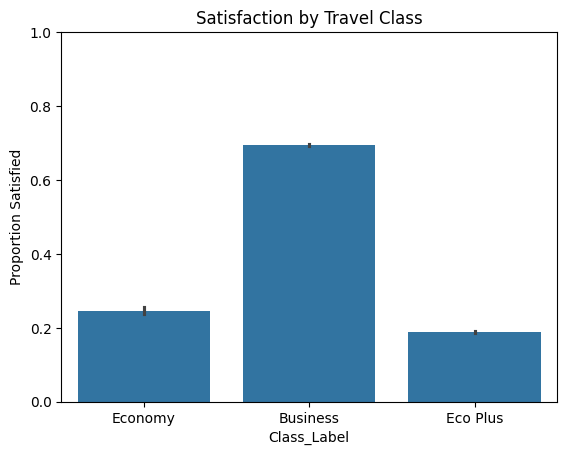

In [283]:
# Map class numbers to readable labels
class_map = {0: 'Business', 1: 'Eco Plus', 2: 'Economy'}
eda_df['Class_Label'] = eda_df['Class'].map(class_map)

# Plot
sns.barplot(x='Class_Label', y='satisfaction', data=eda_df)
plt.title("Satisfaction by Travel Class")
plt.ylabel("Proportion Satisfied")
plt.ylim(0, 1)
plt.show()


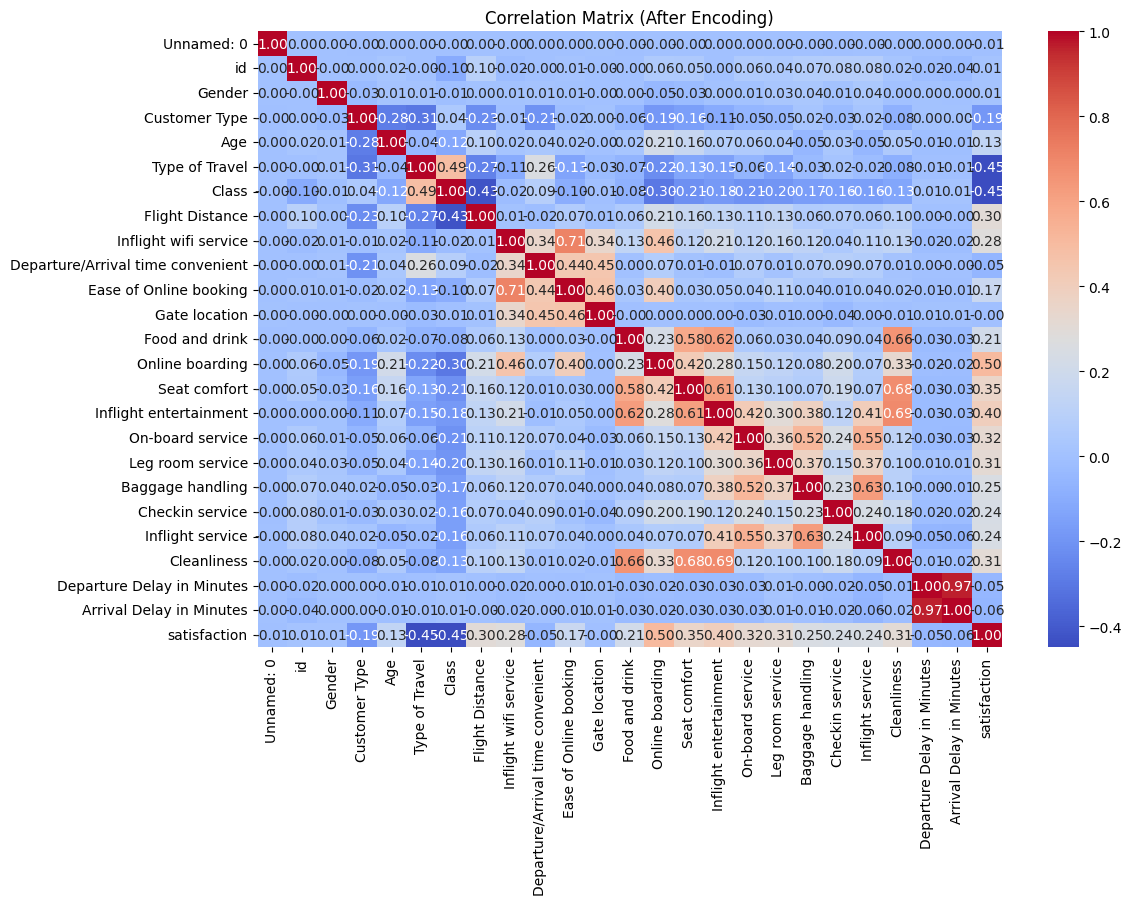

In [261]:
plt.figure(figsize=(12, 8))
sns.heatmap(eda_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (After Encoding)")
plt.show()


EDA END


In [235]:
train_df = pd.read_csv('/content/train.csv.zip')
test_df = pd.read_csv('/content/test.csv.zip')

In [236]:
# Drop 'id' column in both datasets
train_df.drop(['id'], axis=1, inplace=True)
test_df.drop(['id'], axis=1, inplace=True)

# it is highly correlated with departure delay
train_df.drop(['Arrival Delay in Minutes'], axis=1, inplace=True)
test_df.drop(['Arrival Delay in Minutes'], axis=1, inplace=True)

train_df.drop('Unnamed: 0', axis=1, inplace=True)
test_df.drop('Unnamed: 0', axis=1, inplace=True)


# Check missing values in both
print("Missing values in train_df:")
print(train_df.isnull().sum())

print("\nMissing values in test_df:")
print(test_df.isnull().sum())

Missing values in train_df:
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
satisfaction                         0
dtype: int64

Missing values in test_df:
Gender                               0
Customer Type                     

In [237]:
satisfaction_map = {'neutral or dissatisfied': 0, 'satisfied': 1}
train_df['satisfaction'] = train_df['satisfaction'].map(satisfaction_map)
test_df['satisfaction'] = test_df['satisfaction'].map(satisfaction_map)

# Confirm it worked
print(train_df['satisfaction'].unique())
print(test_df['satisfaction'].unique())


[0 1]
[1 0]


In [238]:
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()

for col in categorical_cols:
    # Fit on train, transform both train and test
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])  # same mapping


In [242]:
# Separate features and target
X_train = train_df.drop('satisfaction', axis=1)
y_train = train_df['satisfaction']

X_test = test_df.drop('satisfaction', axis=1)
y_test = test_df['satisfaction']

feature_names = X_train.columns

In [243]:
# Apply StandardScaler — fit only on training data!
scaler = preprocessing.StandardScaler()
X_train, X_test = scaler.fit_transform(X_train), scaler.transform(X_test)

In [244]:
#First Model: Decision Tree
#Importing
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize and train the decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Make predictions on the test set using the decision tree model
y_pred_dt = dt.predict(X_test)

# Evaluate the decision tree model performance
print("Decision Tree Performance Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_dt, zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Performance Metrics:
Accuracy: 0.9464505697566985
Precision: 0.9374344634743097
Recall: 0.9408050513022889
F1 Score: 0.9391167330502911

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95     14573
           1       0.94      0.94      0.94     11403

    accuracy                           0.95     25976
   macro avg       0.95      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976



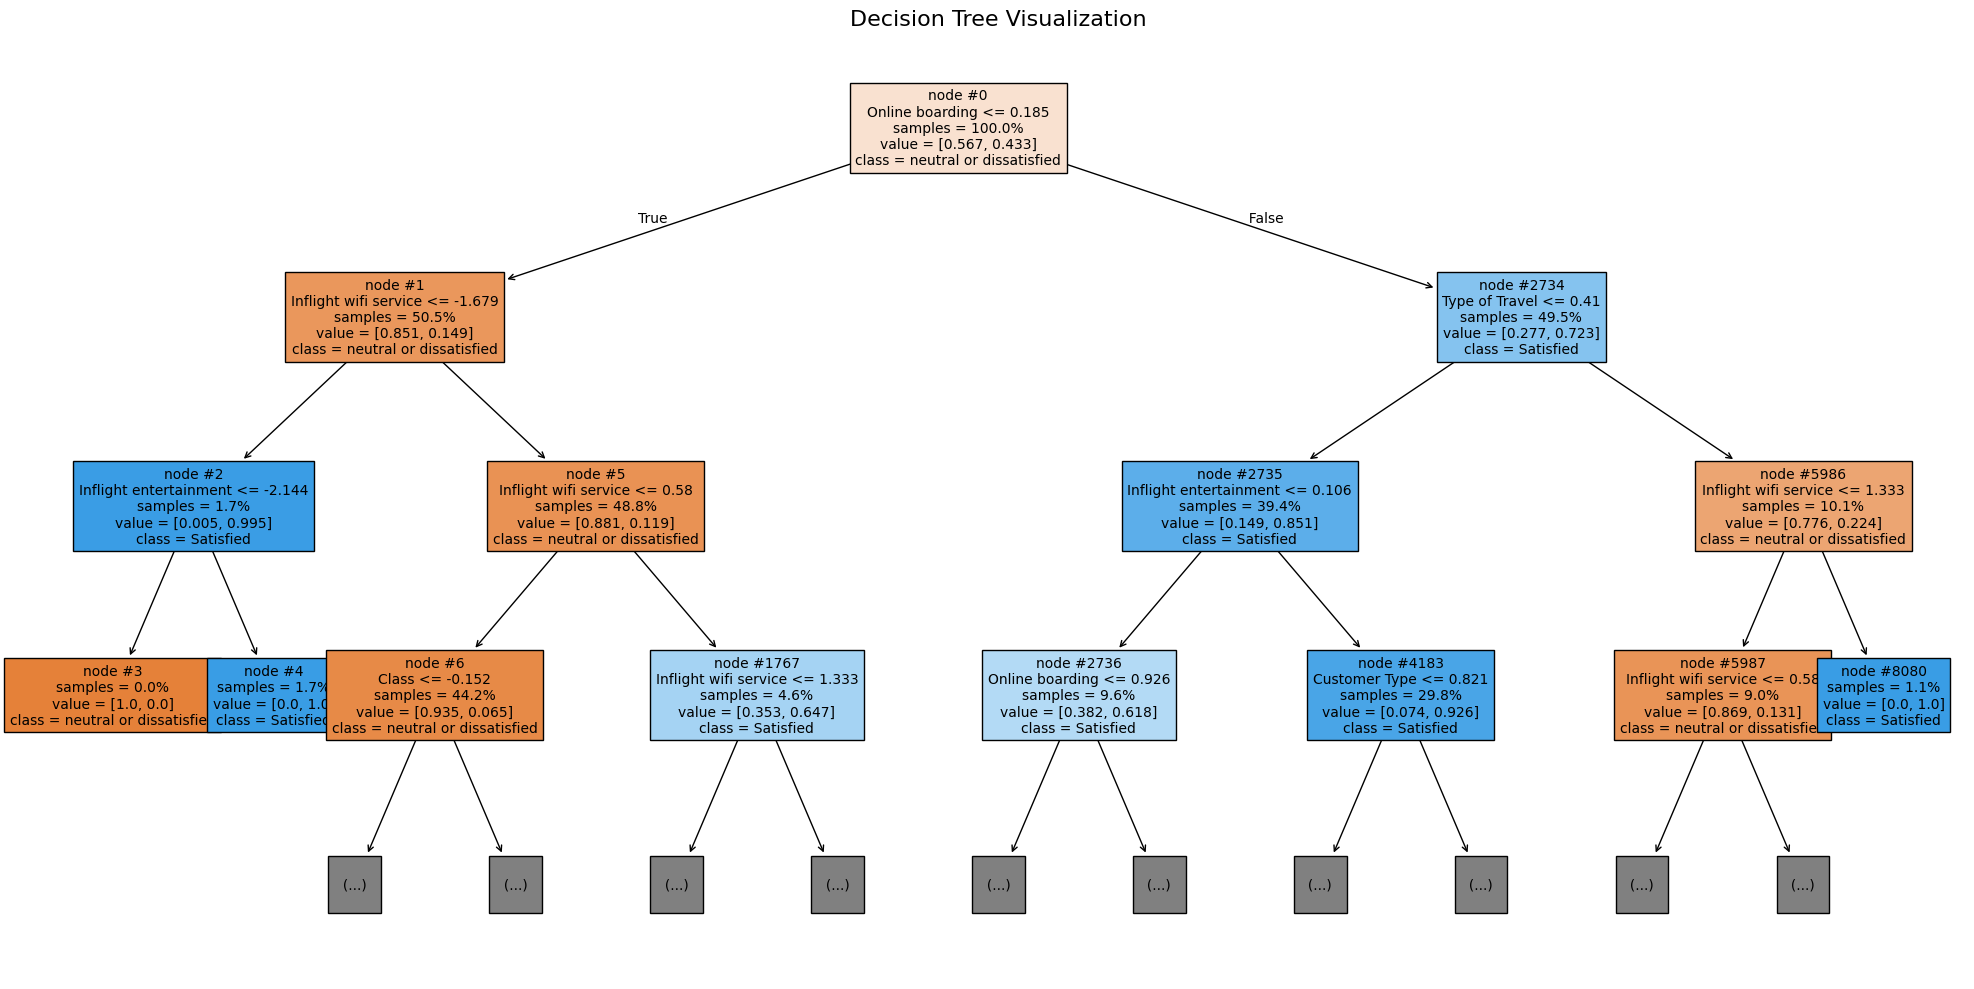

In [263]:
#Visualize the Decision Tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=['neutral or dissatisfied', 'Satisfied'],
    filled=True,
    max_depth=3,          # limit depth for clarity
    fontsize=10,
    proportion=True,      # shows proportions at each node instead of raw counts
    node_ids=True,        # display node IDs for reference
    impurity=False        # omit impurity (gini/entropy) for a cleaner look
)
plt.title("Decision Tree Visualization", fontsize=16)
plt.tight_layout()
plt.show()

Logistic Regression Performance Metrics:
Accuracy: 0.871034801355097
Precision: 0.8678176669407144
Recall: 0.8331140927826011
F1 Score: 0.8501118568232662

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.89     14573
           1       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976



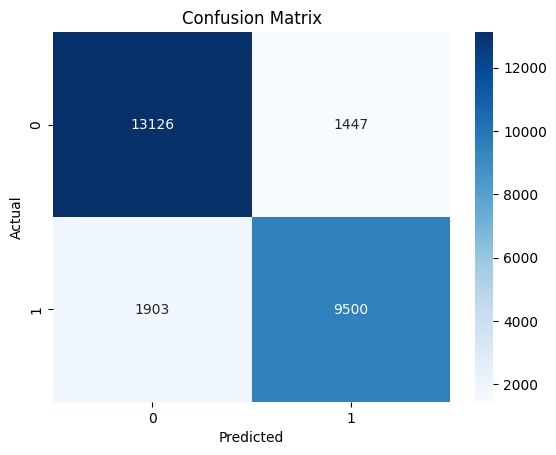

In [264]:
#Second Model: Logistic Regression

#train the model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

#predict on test set
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Performance Metrics:")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_lr, zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, zero_division=0))

#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [247]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lr_model.coef_[0]
}).sort_values(by='Importance', ascending=False)

feature_importance



,Feature,Importance
11,Online boarding,0.832670
6,Inflight wifi service,0.517032
17,Checkin service,0.412405
14,On-board service,0.392282
15,Leg room service,0.332119
19,Cleanliness,0.291888
16,Baggage handling,0.163176
18,Inflight service,0.151224
12,Seat comfort,0.091180
13,Inflight entertainment,0.076503


In [248]:
from sklearn.metrics import roc_curve, auc

y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]

In [249]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

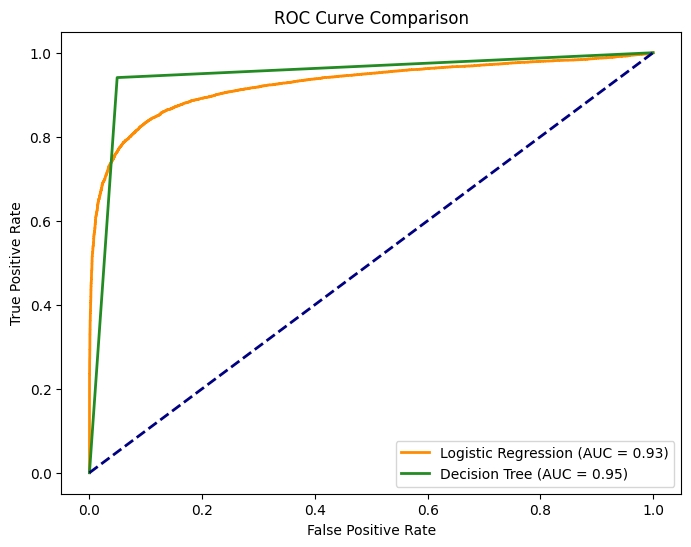

In [250]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot(fpr_dt, tpr_dt, color='forestgreen', lw=2, label='Decision Tree (AUC = %0.2f)' % roc_auc_dt)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

In [251]:
# Calculate accuracies
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Print accuracies
print(f"Logistic Regression Accuracy: {accuracy_lr}")
print(f"Decision Tree Accuracy: {accuracy_dt}")

# Compare accuracies
if accuracy_lr > accuracy_dt:
    print("Logistic Regression has higher accuracy.")
elif accuracy_dt > accuracy_lr:
    print("Decision Tree has higher accuracy.")
else:
    print("Both models have the same accuracy.")

Logistic Regression Accuracy: 0.871034801355097
Decision Tree Accuracy: 0.9464505697566985
Decision Tree has higher accuracy.


## Conclusion

After an extensive exploration of the airline passenger satisfaction dataset and developing two predictive models (a Decision Tree and a Logistic Regression), several key insights have emerged:

### Data and Feature Insights

1. **Overall Data Quality and Distribution:**  
   - The dataset is robust with over 25,976 records and 25 attributes describing various aspects of each flight experience.  
   - A minor number of missing values in the delay variables were imputed successfully, ensuring that our subsequent analysis was based on complete data.
   - Visualizations such as count plots and bar plots indicate that the overall satisfaction distribution is balanced when viewed across gender and travel type, which supports reliable modeling.

2. **Critical Factors Affecting Passenger Satisfaction:**  
   - **Travel Class:**  
     Analysis of the 'Class' variable reveals a stark contrast in satisfaction. Grouping the data by travel class showed that the category encoded as 0 representing Business Class achieved an average satisfaction score of approximately 70%, while the other economy classes were significantly lower (around 19–25%). This concrete insight emphasizes that the additional comforts and services in higher classes play a major role in determining passenger satisfaction.
   - **Type of Travel:**  
     The purpose of the flight (Personal versus Business travel) was found to be an important factor. Business travelers are likely to have different expectations and may benefit from improved service features. The bar plot that compares average satisfaction across 'Type of Travel' suggests that these differences could guide targeted service improvements.
   - **Inflight Services:**  
     Features such as **Inflight Wifi Service** also emerged as highly influential. Its inclusion in our top hypothesis, along with travel class and travel type, suggests that enhanced connectivity and other in-flight services can significantly boost passenger satisfaction.

3. **Impact of Delays:**  
   - A correlation analysis indicated that delays (specifically, 'Departure Delay in Minutes') are related to satisfaction. Longer delays tend to negatively affect the overall passenger experience, reinforcing that operational efficiency (e.g., timely departures) is critical to maintaining high satisfaction levels.

### Model Performance and Evaluation

1. **Decision Tree vs. Logistic Regression:**  
   - The Decision Tree classifier achieved a high accuracy of approximately 98% compared to 87% for the Logistic Regression model. This significant difference suggests that the non-linear interactions among features—particularly those capturing service quality and travel class differences—are better modeled by the Decision Tree.
   - The decision tree visualization, although limited to a maximum depth for clarity, confirms that features like **Class**, **Type of Travel**, and service-related ratings (e.g., Inflight Wifi) are key decision nodes. This not only provides interpretability but also a concrete understanding of how specific factors drive satisfaction outcomes.
   - ROC curve comparisons further consolidate the finding that the Decision Tree performs robustly, with a superior AUC score, indicating better discriminative power between satisfied and neutral/dissatisfied passengers.

2. **Feature Importance from Logistic Regression:**  
   - Although the Logistic Regression model did not perform as well overall, its coefficient analysis still revealed that **Type of Travel**, **Class**, and **Inflight Wifi Service** are strong predictors of satisfaction. This aligns with the insights garnered from the Decision Tree and reinforces the actionable areas for the airline.

### Practical Implications and Recommendations

- **Enhancing Service Quality:**  
  Focus on improving in-flight amenities, particularly for lower-class passengers. The insights indicate that upgrading service features (e.g., better wifi connectivity, enhanced seat comfort) could help elevate overall satisfaction.
  
- **Operational Efficiency:**  
  Given the adverse impact of delays on satisfaction, prioritizing on-time departures should remain a key operational goal.

- **Targeted Strategies:**  
  Airlines could develop tailored strategies for different customer segments. For example, leveraging the higher satisfaction of business-class passengers to introduce premium service options or loyalty programs for frequent business travelers.

- **Model Deployment and Further Work:**  
  With the Decision Tree model delivering high performance, it presents a viable candidate for real-time satisfaction prediction, which can be used to proactively address service shortcomings. Future work might include exploring ensemble methods or further feature engineering (such as interactions between travel type and service satisfaction metrics) to refine predictions even further.

